<a href="https://colab.research.google.com/github/kashishm823-a11y/Rock-vs-Mine-Prediction/blob/main/Data_Cleaning_%26_Visualization_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [7]:
df = pd.read_csv('/content/archive.zip')
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


In [10]:
df.shape

(8807, 12)

In [11]:
df.columns

Index(['show_id', 'type', 'title', 'director', 'cast', 'country', 'date_added',
       'release_year', 'rating', 'duration', 'listed_in', 'description'],
      dtype='object')

In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       8807 non-null   object
 1   type          8807 non-null   object
 2   title         8807 non-null   object
 3   director      6173 non-null   object
 4   cast          7982 non-null   object
 5   country       7976 non-null   object
 6   date_added    8797 non-null   object
 7   release_year  8807 non-null   int64 
 8   rating        8803 non-null   object
 9   duration      8804 non-null   object
 10  listed_in     8807 non-null   object
 11  description   8807 non-null   object
dtypes: int64(1), object(11)
memory usage: 825.8+ KB


In [13]:
df.describe()

,release_year
count,8807.000000
mean,2014.180198
std,8.819312
min,1925.000000
25%,2013.000000
50%,2017.000000
75%,2019.000000
max,2021.000000


## Data Cleaning

In [14]:
df.isnull().sum() # checking missing values

,0
show_id,0
type,0
title,0
director,2634
cast,825
country,831
date_added,10
release_year,0
rating,4
duration,3


In [15]:
# Handle missing values

df.fillna(0, inplace=True)

In [33]:
# Remove duplicates
df.drop_duplicates(inplace=True)

In [41]:
df['country'] = df['country'].fillna('Unknown')
df['rating'] = df['rating'].fillna('Not Rated')

## Data Visualization

Basic Graph Comparison of Movies vs. TV shows

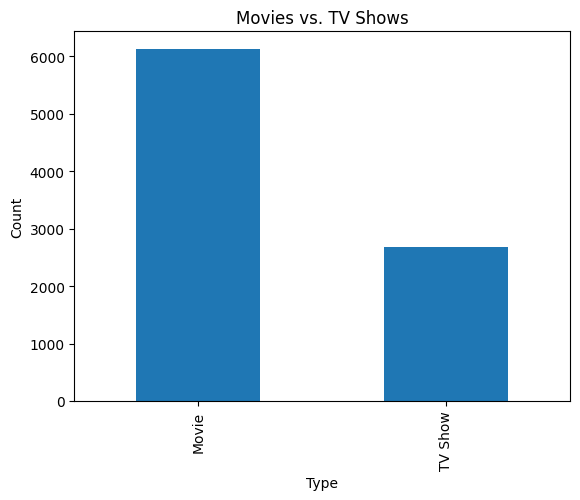

In [42]:
df['type'].value_counts().plot(kind='bar')
plt.title("Movies vs. TV Shows")
plt.xlabel("Type")
plt.ylabel("Count")
plt.show()

# Growth of Netflix

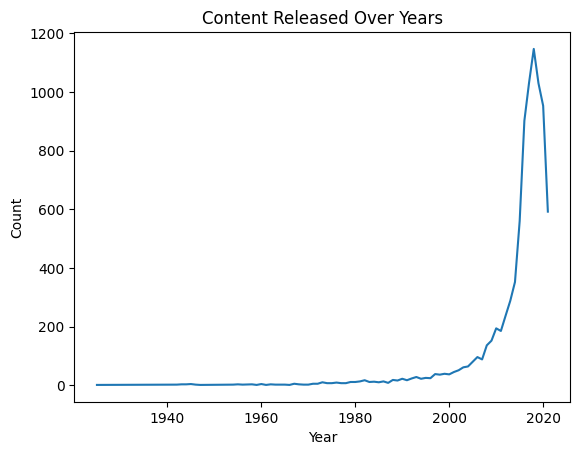

In [43]:
df['release_year'].value_counts().sort_index().plot()
plt.title("Content Released Over Years")
plt.xlabel("Year")
plt.ylabel("Count")
plt.show()

# Top 10 Countries

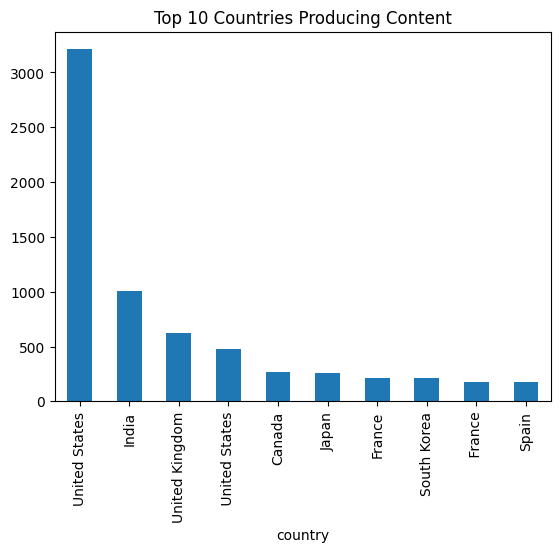

In [47]:
df['country'].str.split(',').explode().value_counts().head(10).plot(kind='bar')
plt.title("Top 10 Countries Producing Content")
plt.xticks(rotation=90)
plt.show()

# Most Common Ratings


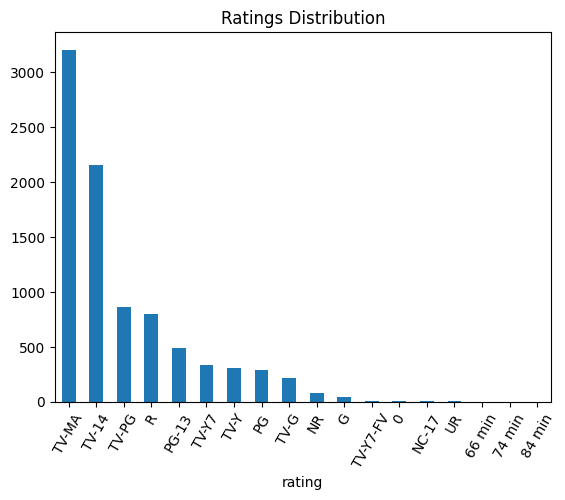

In [38]:
df['rating'].value_counts().plot(kind='bar')
plt.title("Ratings Distribution")
plt.xticks(rotation=60)
plt.show()

# Genre Analysis

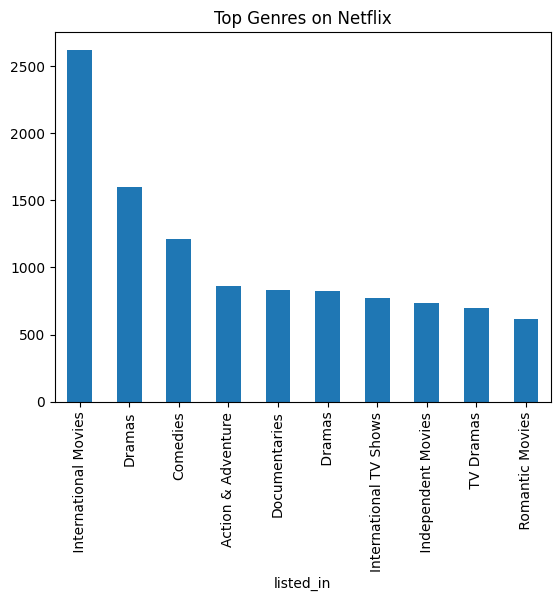

In [39]:
df['listed_in'].str.split(',').explode().value_counts().head(10).plot(kind='bar')
plt.title("Top Genres on Netflix")
plt.xticks(rotation=90)
plt.show()

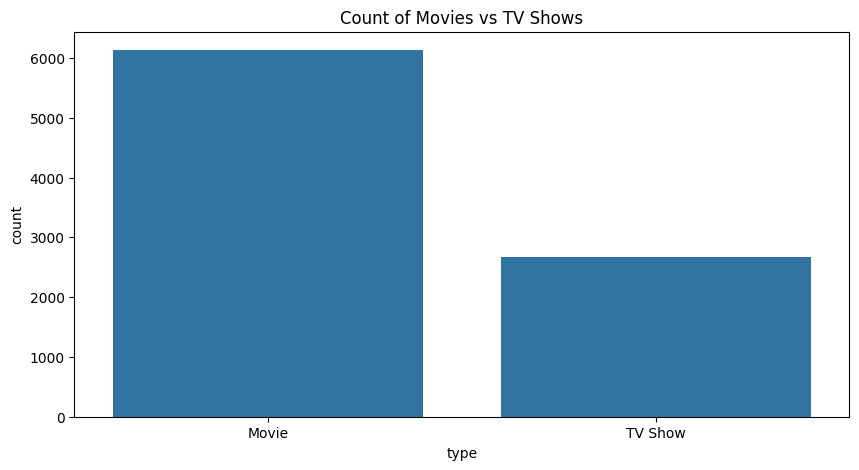

In [40]:
plt.figure(figsize=(10,5))
sns.countplot(x='type', data=df)
plt.title("Count of Movies vs TV Shows")
plt.show()